In [1]:
import pandas as pd
df = pd.read_csv("/group/jrwhitehill/amicorpus/ES2005d/artifacts/log_probs_whisper_tiny_diarized_transcript.csv")

In [2]:
df.head()

,Unnamed: 0,start_time,end_time,speaker,text,gt_text,avg_logprob,sum_logprob,min_logprob,n_tokens
0,0,41,42,D,Okay.,Okay.,-6.96875,-13.9375,-9.1875,2
1,1,42,43,A,"I was thinking,","Okay, almost there.",-4.84375,-19.3750,-9.3125,4
2,2,43,50,C,Okay. I'll use the powerpoint again. How was t...,"Okay. We'll sta I'll use the PowerPoint, I gue...",-3.75000,-67.5000,-9.2500,18
3,3,50,53,D,Hmm. Yep. Very fun.,Mm.,-5.43750,-38.0000,-10.4375,7
4,4,53,68,C,"Okay. Oh, I forgot to mail you a few minutes. ...",Okay. Uh oh I've forgotten to mail you the min...,-4.40625,-110.5000,-9.2500,25


In [3]:
from llm_asr_clarification.models import OracleTranscript
import re

# Fills in ground truth column
file_gt_path = "/group/jrwhitehill/amicorpus/ES2005d/transcripts/parsed_diarized_gt.txt"
gt_transcript = OracleTranscript(file_gt_path, logger='a')
gts = [gt_transcript.get_oracle_transcription(s_time, e_time) for s_time, e_time in zip(df['start_time'], df['end_time'])]

pattern = (
        r"\[Speaker ([A-Z])\]:\s*"
        r"(.*)"
    )

def match(line):
    m = re.match(pattern, line)
    if m:
        line_dict = {
            "speaker": m.group(1),
            "text": m.group(2),
        }
    return line_dict['text']

gts = ["...".join(match(line) for line in gt) if len(gt) > 0 else None for gt in gts ]
df['gt_text'] = gts
df = df.dropna()


In [20]:
import evaluate
from tqdm.auto import tqdm

rouge = evaluate.load("rouge")

def rouge_l_score(pred, ref):
    return rouge.compute(
        predictions=[pred],
        references=[ref]
    )["rougeL"]

df["rougeL"] = [
    rouge_l_score(pred, ref)
    for pred, ref in tqdm(
        zip(df["text"], df["gt_text"]),
        total=len(df)
    )
]

100%|██████████| 216/216 [00:23<00:00,  9.20it/s]


In [4]:
import matplotlib.pyplot as plt

def plot_dist(field):
    ax = df[field].hist(bins=10, grid=False)

    # Set the title and axis labels
    ax.set_title(f'Distribution of {field} in transcript')
    ax.set_xlabel('log probs')
    ax.set_ylabel('freq')

    plt.show()

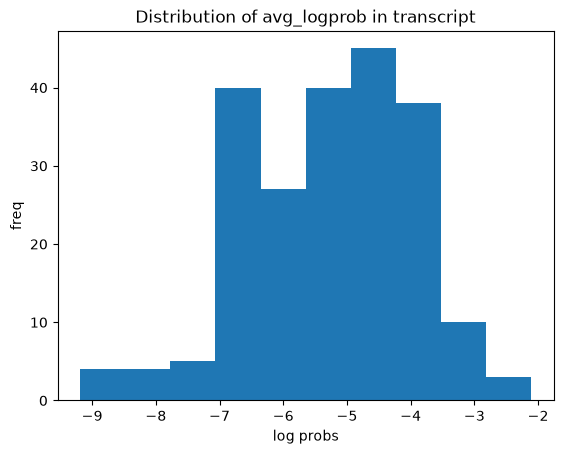

In [5]:
plot_dist('avg_logprob')

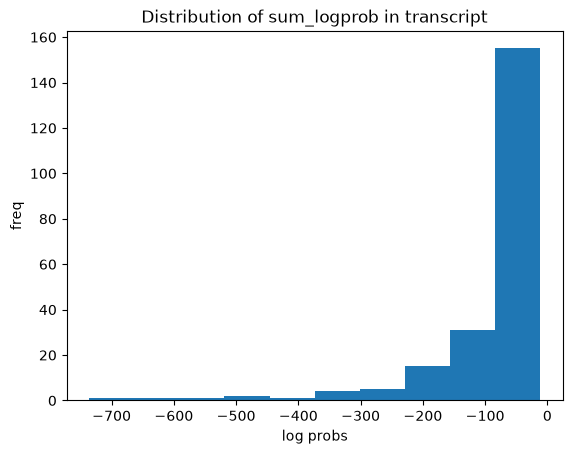

In [6]:
plot_dist('sum_logprob')

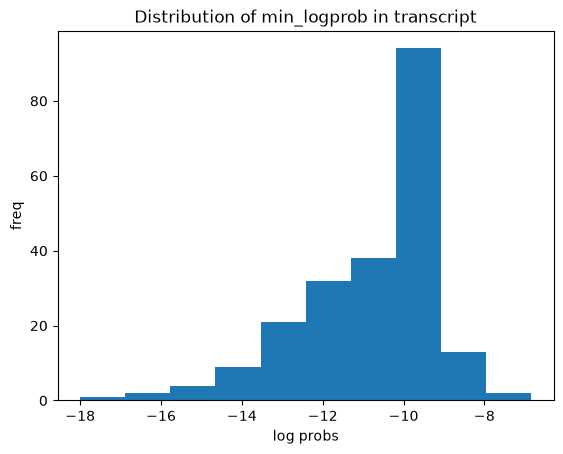

In [7]:
plot_dist('min_logprob')

In [8]:
pd.set_option('display.max_colwidth', None)

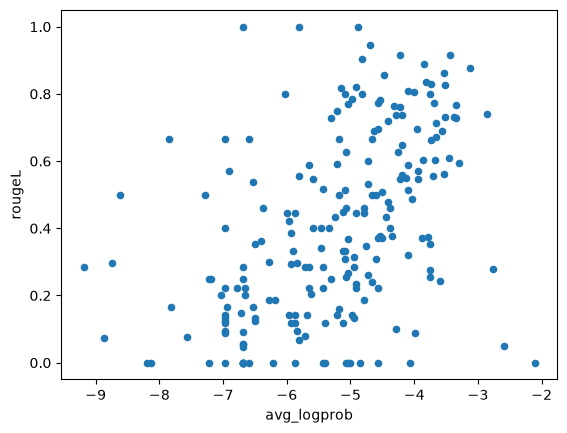

In [24]:
df.plot.scatter(x='avg_logprob', y='rougeL')

# Display the plot
plt.show()

In [26]:
from scipy.stats import pearsonr

result = pearsonr(df['avg_logprob'], df['rougeL'])

print(f"Pearson r: {result.statistic:.4f}")
print(f"P-value: {result.pvalue:.4f}")

Pearson r: 0.4678
P-value: 0.0000


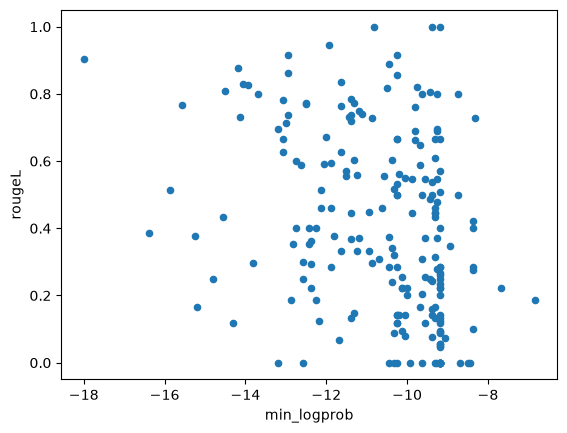

In [25]:
df.plot.scatter(x='min_logprob', y='rougeL')

# Display the plot
plt.show()

# Using average log prob

In [21]:
field = 'avg_logprob'

# Gets the 10 lines with lowest sequence normalized log probs
df.sort_values(by=field)[['start_time','text', 'gt_text', 'n_tokens', 'rougeL',field]][(df['n_tokens'] > 5)].head(10)

/tmp/ipykernel_3405772/1364688748.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df.sort_values(by=field)[['start_time','text', 'gt_text', 'n_tokens', 'rougeL',field]][(df['n_tokens'] > 5)].head(10)


,start_time,text,gt_text,n_tokens,rougeL,avg_logprob
166,1118,This user requirement is essentially just to offer.,"S So what do you think you will personally give....Um so....When the user requirement is essentially just to operate the T_V_, so yeah, of course we haven't actually got a working model yet....Does it work?",9,0.250000,-7.21875
143,795,We're about eight ourselves.,"Oh ok Uh....We evaluated ourselves, we thought we were great.",6,0.250000,-7.18750
216,1659,So we're jumping once.,So yeah....Champagne lunch anyone?,6,0.200000,-7.03125
60,413,More like a traditional or making trouble.,More like a traditional remote control....Um.,8,0.571429,-6.90625
168,1125,"So, what rating you will personally?","S So what do you think you will personally give....When the user requirement is essentially just to operate the T_V_, so yeah, of course we haven't actually got a working model yet....I would say seven.",8,0.222222,-6.65625
193,1358,How can forms to the current trends?,How it how conforms to the current trends?,8,0.666667,-6.59375
140,790,Is the project evaluated that is why in that?,"Oh ok Uh....S Uh is the project evaluated, that is mine....Oh you're doing that.",10,0.538462,-6.53125
131,774,"I just, my needle. So there presentation. All right.","At last mine is also the presentation....Oh right, okay, you've got more, okay.",13,0.166667,-6.53125
122,754,Maybe she's starting cleaning out the play.,Uh maybe we should start cleaning up the clay.,9,0.352941,-6.50000
100,659,I think you're. Quite smoothly.,Oh we've been writing this up for m months....I think it went quite smoothly.,8,0.363636,-6.40625


In [23]:
df.sort_values(by=field, ascending=False)[['start_time','text', 'gt_text', 'n_tokens', 'rougeL',field]].head(10)

,start_time,text,gt_text,n_tokens,rougeL,avg_logprob
22,146,You're so tall. You're so tall. You're so tall. You're so tall.,"Um one's based on the banana, one's based on the tomato and the other one is st Look....What tomato?...I don't recall a tomato.",20,0.000000,-2.109375
34,201,Yeah. Yeah. Yeah. Yeah. Yeah.,"Uh can I have Oh sorry s Mm-hmm....Well I like the feel of it, I like the feel of it....Yeah, sure....Um that one is Oh no, it's delicate....At Oh dear.",10,0.048780,-2.593750
93,586,"Yeah. Okay, so. Oh, that's good. Oh, no, no, no. Um, right. So that's fine. So I don't know what can we, what can we, right? Can we get in? Yeah.","Yeah....Cancel....Piss off....That's too bad....Oh well, never mind....Right, so that's finances and I dunno what we what could we reckon we could add?...Um Well I suppose that's our that's that's our design that we've got....Well maybe we could add something, but maybe if What do you th We're trying to save money, so.",51,0.280000,-2.765625
64,437,"Double curve on both sides. Yeah, this is double curve. This is double curve. This one is single curve. This is single curve. This is one both sides.","And double curve on both sides?...Curve....Yeah, this is double-curve, no?...That's sort of curve in and out....This is double-curve....Is i Mm....It This one is single curve....'Cause this is single curve, this is curved on both sides.",35,0.739726,-2.859375
156,874,"So, now is the final evaluation. Final evaluation of the rubber of our product. How we are going to means at what standards, what standard it, whether it means of a standards or not. How we're trading, we will give to these putters. So, of course, this will be a team work. We together have to decide what rating we will give to this product and everything. But methodology I will tell you on what basis we are going to discuss all this. We will give the rating to this product based on the user requirements. Whether it meets the user requirements or not. This product then trends. Whether it is as per the latest fashion trends or not. Means, because we have already studied that people do prefer fashionable things nowadays. So, this is also an important factor for evaluation also. Then marketing strategy of the company. As we have already discussed that our company is quite rapid in the market. Not only in terms of providing quality products, not only in providing latest technologies, but also in terms of providing environmental.","Oh could you pass the tomato please....Sorry....So now is the final evaluation, final evaluation of the uh uh of our product....How we are going to means uh at what standard what standard whether it meets our standards or not....How mu What rating we will give to these products....So of course this is will be a team work, w we together have to decide wha what rating we will give to this product and everything....Okay....So what methodology I will tell you on what basis we are going to discuss all this....We will give the rating to this product based on the user requirements, whether it meets the user requirements or not, this product....Then trends, whether it is as fashion trends or not?...Means because we have already stated that people do prefer fashionable things nowadays....Mm-hmm....So this is also an important factor for our evaluation also....Then marketing strategy of the company....As we have already discussed that our company is quite in the market, not only in terms of providing quality products, not only in pro providing latest technologies, but also in terms of providing environmental s Yeah.",211,0.877285,-3.125000
89,570,"No, it's not like the shift button. Yeah, it's not like that.","Shift....No it's not....No, it's 'cause the uh the shift button's stuck, or something....Yeah, it's not working.",18,0.594595,-3.296875
61,415,"Yeah. I mean, it's already got a kind of cool shape. So we didn't have to be curved in and out. And by doing so, I don't know, although it doesn't save us quite as much. I don

# Using min log prob

In [12]:
field = 'min_logprob'
df.sort_values(by=field)[['text', 'gt_text', 'n_tokens', field]].head(10)

,text,gt_text,n_tokens,min_logprob
201,"Okay, well, I think it's the very remote control conforms to the company strategy.","Okay....Well, I think it's the the remote control conforms to the the company strategy.",18,-18.0000
124,"So, is it go back in? We, we usable.","So So Uh Brian, have you have you finished?...Does it go back in, does it?...Reusable.",13,-16.3750
184,"Maybe, okay, but I will, I will personally want to give it a trending, we want three. Okay. So we can, we have one and every, we can think, three or four. Maybe three or four? No, sorry, it should six.","Uh maybe....Okay but I will I will personally won't give it beyond three....No, I mean uh obviously your opinion, I'm just trying to Okay....So we can Yeah, on an average we can think three, four sevenths, maybe....He's a tough cookie....Three or four?...Uh, no sorry, it should be No sorry, sorry, sorry, sorry, we are doing a very wrong thing.",55,-15.8750
61,"Yeah. I mean, it's already got a kind of cool shape. So we didn't have to be curved in and out. And by doing so, I don't know, although it doesn't save us quite as much. I don't know what to go on with this again.","Yeah, I mean it's already got a kind of cool shape, so but it wouldn't have to be curved sort of in and out....Mm-hmm....Mm-hmm....And by doing so Oh no, hold on....Doesn't save us quite as much....I don't know what's going on with this again.",59,-15.5625
90,"Should we ask how we're, should we ask how we're taking it? It's for the Melissa.",Is it the other shift button maybe?...Should we ask Meli Should we ask our technical expert Melissa?,22,-15.2500
131,"I just, my needle. So there presentation. All right.","At last mine is also the presentation....Oh right, okay, you've got more, okay.",13,-15.1875
143,We're about eight ourselves.,"Oh ok Uh....We evaluated ourselves, we thought we were great.",6,-14.8125
45,"Obviously, I don't think that's real sized thing, who would have to be a bit bigger.","Uh can I have Oh sorry s Mm-hmm....Well, if you hold it, you can you all can hold it, is it does actually feel quite ergonomic, if you've got small hands....Yeah....Um, obviously I don't think that's real sized....Okay....It would have to be a bit bigger....Yeah, okay.",21,-14.5625
37,"That's, that's already got it stand that one. That's it stand. That's it. It does also lie flat, but that's the, that yellow stand there represents the, the charging stand. Okay. The black on the back is the slogan.","Uh can I have Oh sorry s Mm-hmm....That's that's already got its stand that one....That's it stand....Alright, okay....It does also lie flat, but that's the that yellow stand there represents the the charging stand....Okay, brilliant mm....Um the black on the back is the slogan.",54,-14.5000
181,Yeah. Is that not trends? Ah.,"Being fruitist....Is that no is that not trends?...Uh no, uh personally as a Marketing Expert I don't believe that, because whatever companies they launch their products in the shape of fruits, they give a range of products, a range of shapes, like if we see, look at the smallest thing, toffee chocolates, they give a variety of different things.",9,-14.3125


In [13]:
df.sort_values(by=field, ascending=False)[['text', 'gt_text', 'n_tokens', field]].head(10)

,text,gt_text,n_tokens,min_logprob
167,Does it work? Yeah.,"S So what do you think you will personally give....When the user requirement is essentially just to operate the T_V_, so yeah, of course we haven't actually got a working model yet....Does it work?...Yeah.",6,-6.84375
107,Leadership.,Great leadership....Excellent leadership....Thank you very much.,3,-7.68750
203,Is that the question?,"Okay....Yeah, yeah....Is that the question?",5,-8.31250
17,You're new. Maybe we should bring them. Okay.,Um maybe we should bring so that the camera can see.,12,-8.37500
133,You've got more.,"Oh, you got a presentation, sorry....Yeah, yeah....Sorry uh.",5,-8.37500
12,You have a bunch of problems. I thought you'd have this one.,I'm afraid you're all sacked....Cutbacks....Oops....I don't even have this on.,15,-8.37500
62,"What, why is the double curve too, I think?",W why is the uh double curved two of them?,12,-8.37500
160,"You should do it. So, you will be required.","The board working again, is it?...the user requirem I think.",12,-8.37500
139,Doesn't tell me.,"Oh ok Uh....S Uh is the project evaluated, that is mine.",6,-8.43750
22,You're so tall. You're so tall. You're so tall. You're so tall.,"Um one's based on the banana, one's based on the tomato and the other one is st Look....What tomato?...I don't recall a tomato.",20,-8.50000


# Using sum log probs

In [14]:
field = 'sum_logprob'
df.sort_values(by=field)[['text', 'gt_text', 'n_tokens', field]].head(10)

,text,gt_text,n_tokens,sum_logprob
198,"Okay. Uh, first of all, I mean, I think that in terms of trends, this words are quite good, like, this words are in fruit shape, because that people now, our fashion trend shows that people like everything, everything are, is being advertised like close shoes and everything is being advertised in the form of fruits and vegetables, or getting them, some, some, or showing some association with them. So, and in this way, our product is good, and this second thing now, people don't want any complicated old bulky project and our, since quite simple and quite handy. So, that is also, that also, our product meets the fashion trends of the market. And yes, it is spongy also, so they can play with it, it's quite good. So, then I think maybe I can give it to, so, for, for, it, in 13, 13, but, so we can, is it fine? So, what about company strategy? Say.","Uh Okay....Uh personally I wi uh I think that in terms of trends, these products are quite good, like, these products are in fruit shape, because that wha people now our fashion trend shows that people like everything all f everything that is being advertised, like clothes, shoes, and everything is being advertised in the form of fruits and vegetables, or getting them or showing some association with them....So and in this way our product is good....And the second thing, now people don't want any complicated or bulky products and ours is quite simple and quite handy....Mm-hmm....So that is also ef that also Our product meets the f the fashion uh trends of the market....And yes....It is cus spongy also....So they can play with it, it's quite good....So then I think, maybe I can give it two....So four five ten thirteen thirteen....So we can Is it fine?...So what about company strategy?",209,-736.0
156,"So, now is the final evaluation. Final evaluation of the rubber of our product. How we are going to means at what standards, what standard it, whether it means of a standards or not. How we're trading, we will give to these putters. So, of course, this will be a team work. We together have to decide what rating we will give to this product and everything. But methodology I will tell you on what basis we are going to discuss all this. We will give the rating to this product based on the user requirements. Whether it meets the user requirements or not. This product then trends. Whether it is as per the latest fashion trends or not. Means, because we have already studied that people do prefer fashionable things nowadays. So, this is also an important factor for evaluation also. Then marketing strategy of the company. As we have already discussed that our company is quite rapid in the market. Not only in terms of providing quality products, not only in providing latest technologies, but also in terms of providing environmental.","Oh could you pass the tomato please....Sorry....So now is the final evaluation, final evaluation of the uh uh of our product....How we are going to means uh at what standard what standard whether it meets our standards or not....How mu What rating we will give to these products....So of course this is will be a team work, w we together have to decide wha what rating we will give to this product and everything....Okay....So what methodology I will tell you on what basis we are going to discuss all this....We will give the rating to this product based on the user requirements, whether it meets the user requirements or not, this product....Then trends, whether it is as fashion trends or not?...Means because we have already stated that people do prefer fashionable things nowadays....Mm-hmm....So this is also an important factor for our evaluation also....Then marketing strategy of the company....As we have already discussed that our company is quite in the market, not only in terms of providing quality products, not only in pro providing latest technologies, but also in terms of providing environmental s Yeah.",211,-656.0
180,"For me

In [15]:
df.sort_values(by=field, ascending=False)[['text', 'gt_text', 'n_tokens', field]].head(10)

,text,gt_text,n_tokens,sum_logprob
20,"Um,","Um one's based on the banana, one's based on the tomato and the other one is st Look.",2,-11.6875
138,"Uh,","Oh ok Uh....S Uh is the project evaluated, that is mine....Doesn't tell me.",2,-11.7500
120,"Uh,",Uh Let's see if I can get this bloody thing to work.,2,-11.7500
116,"Uh,",Well um....I suppose yeah.,2,-11.7500
217,Yep.,So yeah....Champagne lunch anyone?,2,-13.1875
24,Yeah.,"So....Ah I see, okay.",2,-13.3750
36,Yeah.,Uh can I have Oh sorry s Mm-hmm....At Oh dear.,2,-13.3750
35,Yeah.,Uh can I have Oh sorry s Mm-hmm....At Oh dear.,2,-13.3750
152,Yeah.,It's fun to touch....Yeah.,2,-13.3750
123,Yeah.,"So So Uh Brian, have you have you finished?",2,-13.3750
